## GMM Model Evaluation

In [54]:
from preprocessing import preprocess
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import umap
import json
from scipy.stats import norm
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.manifold import trustworthiness
from sklearn.model_selection import KFold

RUN_EXPERIMENTS = False

X_scaled, scaler, df, feature_names = preprocess(return_df=True)
df_numeric = df[feature_names]

labels = np.load("labels.npy")

with open("best_params.json") as f:
    best_params = json.load(f)

/Users/megan/Documents/Year 3/Games Project/Games Project Unity/ChronoQuest1/Assets/Scripts/Final Boss ML/preprocessing.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["dash_rate"] = df["dash_count"] / df["session_duration_seconds"]
/Users/megan/Documents/Year 3/Games Project/Games Project Unity/ChronoQuest1/Assets/Scripts/Final Boss ML/preprocessing.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["jump_rate"] = (df["jump_count"] + df["wall_jump_count"] + df["double_jump_count"]) / df["sessi

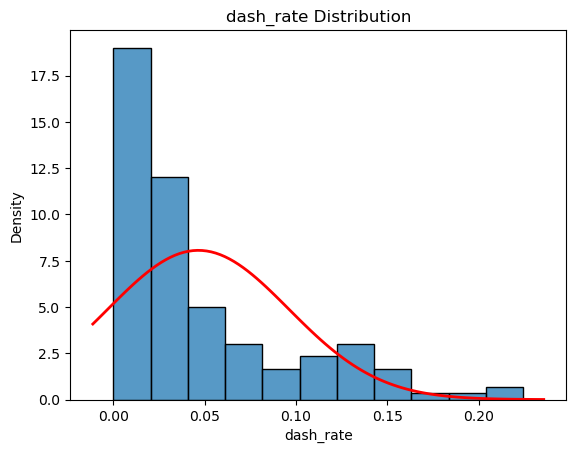

In [55]:
# --- histogram visualisation of dash feature ---
dash_feature = "dash_rate"
data = df_numeric[dash_feature] 

sns.histplot(data, kde=False, stat='density')
mu, std = norm.fit(data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title(f"{dash_feature} Distribution")
plt.show()

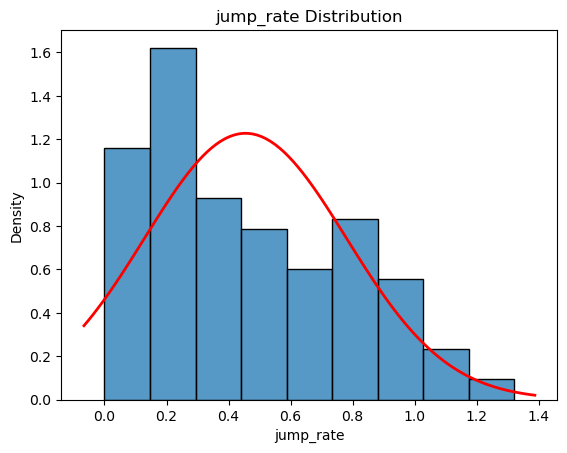

In [56]:
# --- histogram visualisation of jump feature ---
jump_feature = "jump_rate"
jump_data = df_numeric[jump_feature]

sns.histplot(jump_data, kde=False, stat='density')
mu, std = norm.fit(jump_data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title(f"{jump_feature} Distribution")
plt.show()

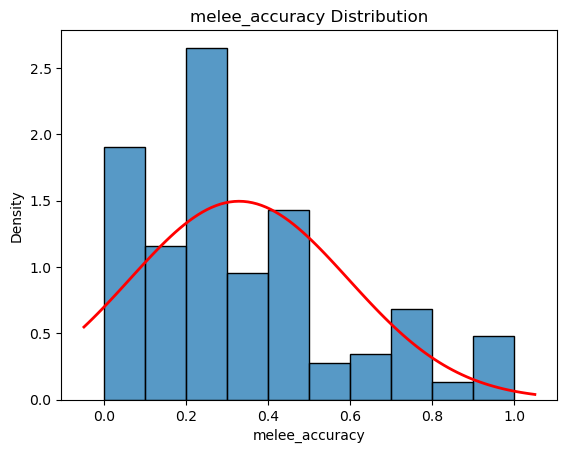

In [57]:
# --- melee feature histogram ---
melee_features = "melee_accuracy"
melee_data = df_numeric[melee_features]

sns.histplot(melee_data, kde=False, stat='density')
mu, std = norm.fit(melee_data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title(f"{melee_features} Distribution")
plt.show()

In [58]:
# --- pca experimentation ---
components = [2, 3, 4]

for n in components:
    pca = PCA(n_components=n)
    X = pca.fit_transform(X_scaled)

    explained = pca.explained_variance_ratio_
    cumulative = explained.cumsum()

    print(f"\n=== PCA: {n} Components ===")
    print("Variance Ratio: ", explained)
    print("Cumulative Variance: ", cumulative)
    print("Singular Values: ", pca.singular_values_)


=== PCA: 2 Components ===
Variance Ratio:  [0.23885957 0.15785284]
Cumulative Variance:  [0.23885957 0.39671242]
Singular Values:  [16.76003749 13.62479153]

=== PCA: 3 Components ===
Variance Ratio:  [0.23885957 0.15785284 0.14464196]
Cumulative Variance:  [0.23885957 0.39671242 0.54135438]
Singular Values:  [16.76003749 13.62479153 13.04219873]

=== PCA: 4 Components ===
Variance Ratio:  [0.23885957 0.15785284 0.14464196 0.12328316]
Cumulative Variance:  [0.23885957 0.39671242 0.54135438 0.66463754]
Singular Values:  [16.76003749 13.62479153 13.04219873 12.04080558]



Metrics
Trustworthiness:  0.8324616538630661
Silhouette Score:  0.11200655609616232
DB Index:  2.613774882989806


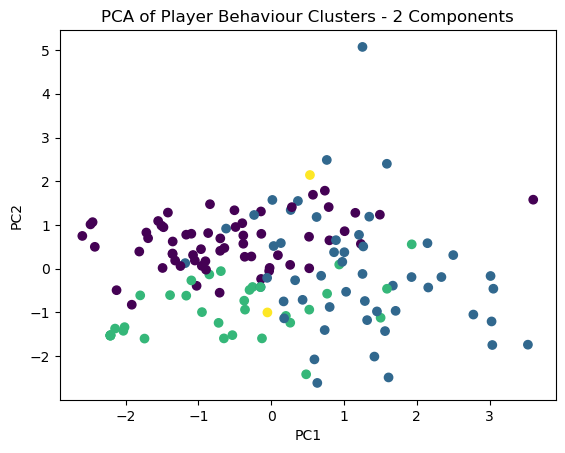

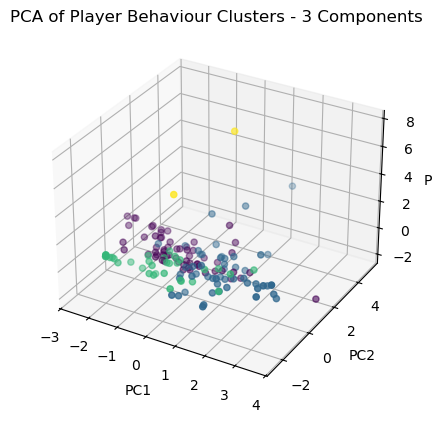

In [59]:
# --- pca for cluster visualisation ---
# two components 
gmm = GaussianMixture(n_components=4, random_state=42)
labels = gmm.fit_predict(X_scaled)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

trust_score = trustworthiness(X_scaled, X_pca, n_neighbors=10)
silhouette_score_pca = silhouette_score(X_pca, labels)
d_b_index_pca = davies_bouldin_score(X_pca, labels)

print(f"\nMetrics")
print("Trustworthiness: ", trust_score)
print("Silhouette Score: ", silhouette_score_pca)
print("DB Index: ", d_b_index_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("PCA of Player Behaviour Clusters - 2 Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# three components 
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=labels)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA of Player Behaviour Clusters - 3 Components")
plt.show()


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


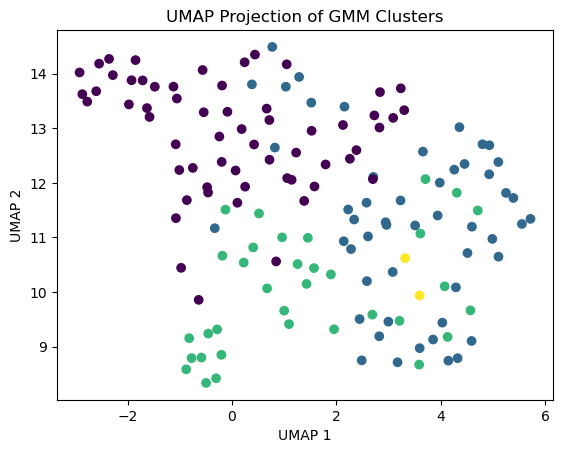

In [60]:
# --- umap for cluster visualisation ---
neighbours = [5, 15, 30]
distance = [0.1, 0.5]

if RUN_EXPERIMENTS:
    for n in neighbours:
            for d in distance:
                umap_model = umap.UMAP(
                    n_neighbors=n,
                    min_dist=d,
                    n_components=2,
                    random_state=42
                )

                X_umap = umap_model.fit_transform(X_scaled)

                # -- metrics --
                trust_score = trustworthiness(X_scaled, X_umap, n_neighbors=n)
                print("Trusthworthiness: ", trust_score)

                silhouette_score_umap = silhouette_score(X_umap, labels)
                print("Silhouette Score: ", silhouette_score_umap)

                d_b_score = davies_bouldin_score(X_umap, labels)
                print("Davies Bouldin Index: ", d_b_score)

                plt.figure()
                plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels)
                plt.xlabel("UMAP 1")
                plt.ylabel("UMAP 2")
                plt.title(f"UMAP Projection (n_neighbours={n}, min_dist={d})")
                plt.show()

# final umap and plot 
final_umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.5,
    n_components=2,
    random_state=42
)

X_final_umap = final_umap_model.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_final_umap[:, 0], X_final_umap[:, 1], c=labels)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title(f"UMAP Projection of GMM Clusters")
plt.show()

Text(0.5, 1.0, 't-SNE Projection of GMM Clusters ')

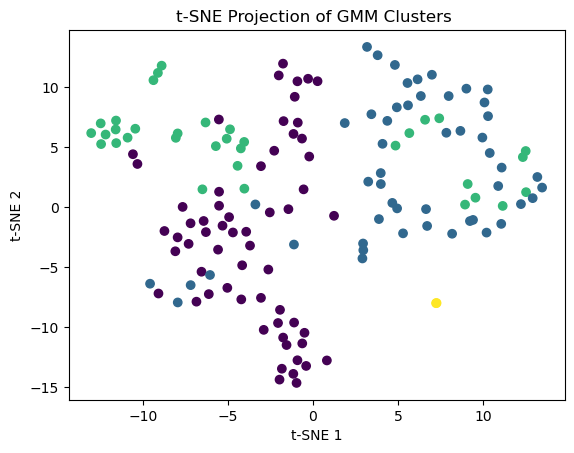

In [61]:
# --- tsne for cluster visualisation --- 
# running through different perplexity values
perplexities = [5, 10, 20, 30]

if RUN_EXPERIMENTS: 
    for p in perplexities:
        tsne = TSNE(
            n_components=2, 
            learning_rate='auto',
            init='random',
            perplexity=p,
            random_state=42
        )

        X_tsne = tsne.fit_transform(X_scaled)

        trust_score = trustworthiness(X_scaled, X_tsne, n_neighbors=10)
        print("Trustworthiness: ", trust_score)

        tsne_silhouette_score = silhouette_score(X_tsne, labels)
        print("Silhouette Score: ", tsne_silhouette_score)

        db_index_tsne = davies_bouldin_score(X_tsne, labels)
        print("DB Index: ", db_index_tsne)

        plt.figure()
        plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels)
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.title(f"t-SNE Projection - (Perplexity={p})")
        plt.show()

# final t-sne fit and plot
final_tsne = TSNE(
    n_components=2,
    learning_rate='auto',
    init='random',
    perplexity=20,
    random_state= 42
)

X_final_tsne = final_tsne.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_final_tsne[:, 0], X_final_tsne[:, 1], c=labels)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection of GMM Clusters ")

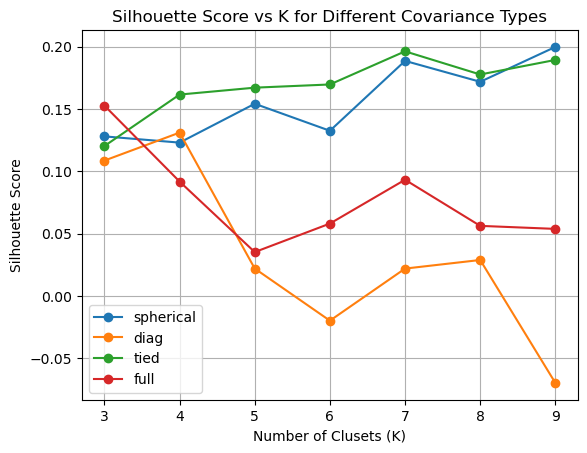

In [62]:
# --- plot for covariance, k and silhouette score ---
# calculating values
results = []

for cov in ["spherical", "diag", "tied", "full"]:
    for k in range(3, 10):
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        labels = gmm.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        
        results.append({
            "covariance": cov, 
            "k": k,
            "silhouette": score
        })

df_results = pd.DataFrame(results)

# plotting the figure
plt.figure() 

for cov in df_results["covariance"].unique():
    subset = df_results[df_results["covariance"] == cov]
    plt.plot(subset["k"], subset["silhouette"], marker="o", label=cov)

plt.xlabel("Number of Clusets (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K for Different Covariance Types")
plt.legend()
plt.grid()
plt.show()

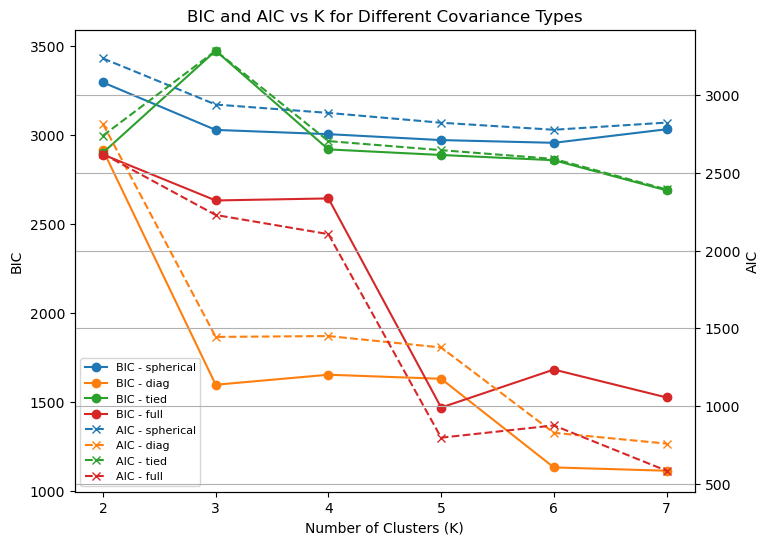

In [63]:
# plots for aic and bic comparison vs K
aic_bic_results = []

for cov in ["spherical", "diag", "tied", "full"]:
    for k in range(2, 8):
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        gmm.fit(X_scaled)

        labels = gmm.predict(X_scaled)

        aic_bic_results.append({
            "covariance": cov,
            "k": k,
            "silhouette": silhouette_score(X_scaled, labels), 
            "bic": gmm.bic(X_scaled),
            "aic": gmm.aic(X_scaled)
        })

        df_aic_bic_results = pd.DataFrame(aic_bic_results)

# --- plotting dual-axis figure ---
fig, ax1 = plt.subplots(figsize=(8, 6))

for cov in df_aic_bic_results["covariance"].unique():
    subset = df_aic_bic_results[df_aic_bic_results["covariance"] == cov]
    ax1.plot(subset["k"], subset["bic"], marker='o', label=f"BIC - {cov}")

ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("BIC")

ax2 = ax1.twinx()
for cov in df_aic_bic_results["covariance"].unique():
    subset = df_aic_bic_results[df_aic_bic_results["covariance"] == cov]
    ax2.plot(subset["k"], subset["aic"], linestyle='--', marker='x', label=f"AIC - {cov}")

ax2.set_ylabel("AIC")

plt.title("BIC and AIC vs K for Different Covariance Types")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=8)
plt.grid()
plt.show()

In [64]:
# TODO cluster sizes? distances and means? 

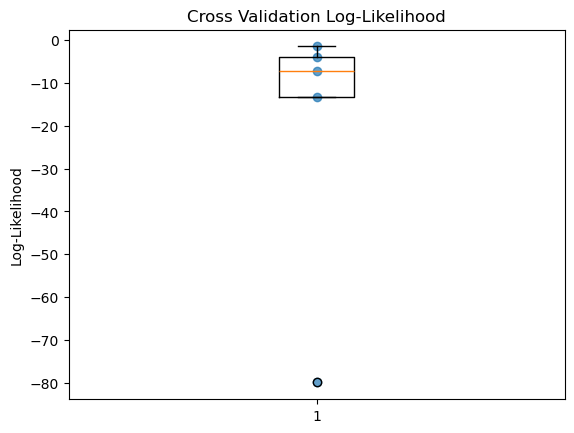

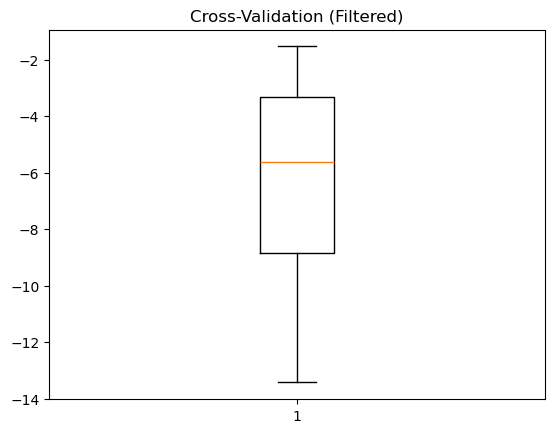

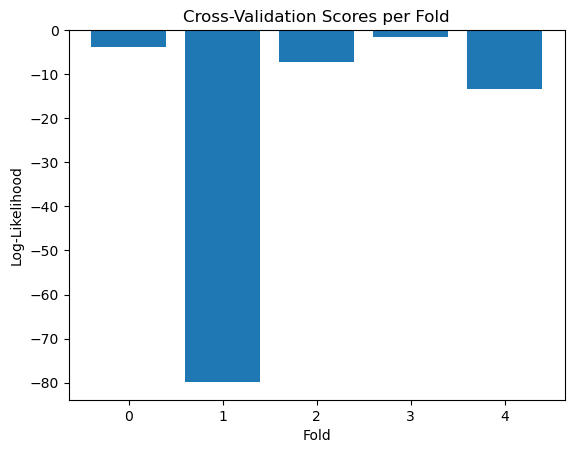

In [65]:
# --- cross-validation visualisation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, test_idx in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]

    gmm = GaussianMixture(
        n_components=best_params["n_components"],
        covariance_type=best_params["covariance_type"],
        random_state=42
    )

    gmm.fit(X_train)
    scores.append(gmm.score(X_test))

# -- box plot version -- 
# with outlier
plt.boxplot(scores)
plt.scatter([1]*len(scores), scores, alpha=0.7)
plt.title("Cross Validation Log-Likelihood")
plt.ylabel("Log-Likelihood")
plt.show()

filtered_scores = [s for s in scores if s > -30]
plt.boxplot(filtered_scores)
plt.title("Cross-Validation (Filtered)")
plt.show()

# -- bar chart version -- 
plt.figure()
plt.bar(range(len(scores)), scores)
plt.xlabel("Fold")
plt.ylabel("Log-Likelihood")
plt.title("Cross-Validation Scores per Fold")
plt.show()